In [3]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

In [7]:
file_path = 'flipkart_data.csv'

In [8]:
df = pd.read_csv(file_path)

In [14]:
df.head()


,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


In [13]:
df.shape

(9976, 2)

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kartik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))

In [35]:
len(stop_words)

198

In [42]:
def preprocess_reviews_stopwords(df):
    df['review'] = df['review'].str.lower()
    df['review'] = df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)
    return df

In [43]:
df

,review,rating
0,nice produt. like design lot. easy carry. and....,5
1,awesome sound....very pretty see nd sound qual...,5
2,awesome sound quality. pros 7-8 hrs battery li...,4
3,think good product per quality also design qui...,5
4,awesome bass sound quality good bettary long l...,5
...,...,...
9971,goodread,5
9972,everything amazimg built light..read,5
9973,goodread,5
9974,best headphone ever used....read,5


In [44]:
print(type(df['rating'].iloc[0]))

<class 'numpy.int64'>


In [45]:
df_cleaned = preprocess_reviews_stopwords(df)

In [46]:
df

,review,rating,sentiment
0,nice produt. like design lot. easy carry. and....,5,1
1,awesome sound....very pretty see nd sound qual...,5,1
2,awesome sound quality. pros 7-8 hrs battery li...,4,1
3,think good product per quality also design qui...,5,1
4,awesome bass sound quality good bettary long l...,5,1
...,...,...,...
9971,goodread,5,1
9972,everything amazimg built light..read,5,1
9973,goodread,5,1
9974,best headphone ever used....read,5,1


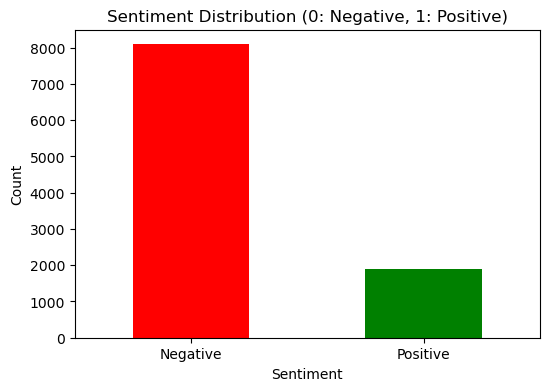

In [53]:
sentiment_counts = df_cleaned['sentiment'].value_counts()
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['red','green'])
plt.title('Sentiment Distribution (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(ticks=[0,1],labels=['Negative','Positive'],rotation=0)
plt.show()

In [54]:
# Word Cloud for Positive Reviews

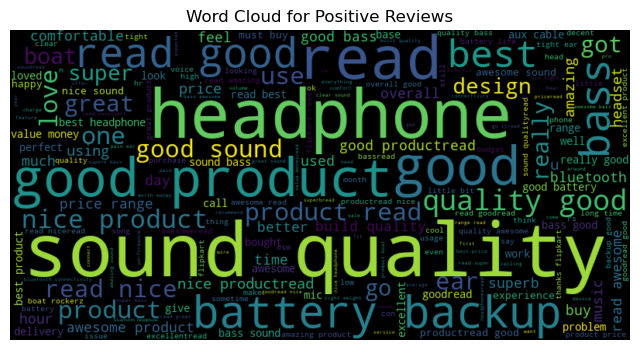

In [62]:
positive_reviews = df_cleaned[df_cleaned['sentiment'] == 1]['review']
positive_text = ' '.join(positive_reviews)
wordcloud = WordCloud(width=800,height=400).generate(positive_text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

In [66]:
vectorizer = TfidfVectorizer(max_features=5000)
X=vectorizer.fit_transform(df_cleaned['review'])
y=df_cleaned['sentiment']

In [64]:
# Model Training, Evaluation and Prediction


In [70]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [73]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)

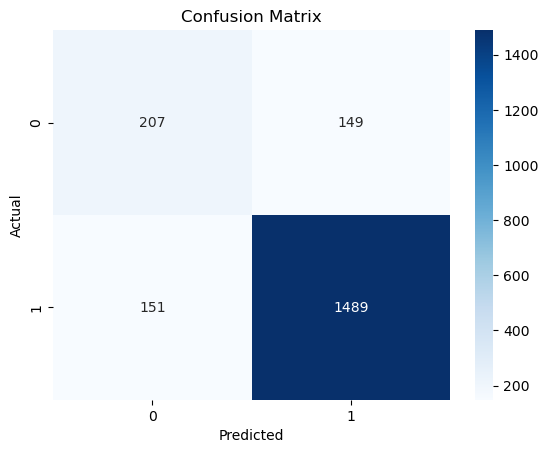

In [75]:


sns.heatmap(conf_matrix,annot=True,fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [76]:
print(accuracy)

0.8496993987975952


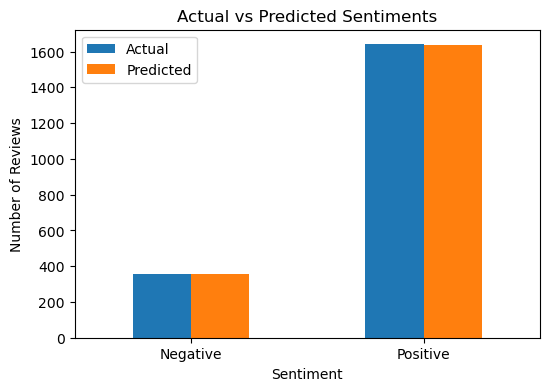

In [77]:
comparison = pd.DataFrame({
    'Actual': y_test.value_counts().sort_index(),
    'Predicted': pd.Series(y_pred).value_counts().sort_index()
})

comparison.index = ['Negative', 'Positive']

comparison.plot(kind='bar', figsize=(6,4))
plt.title("Actual vs Predicted Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

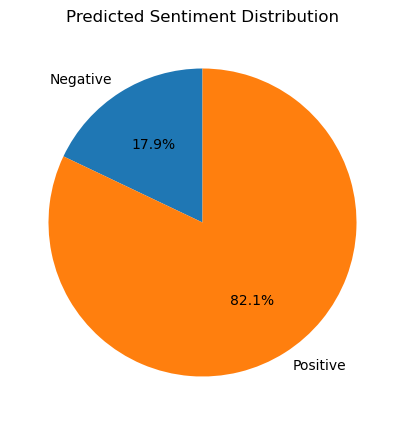

In [78]:
labels = ['Negative', 'Positive']
sizes = pd.Series(y_pred).value_counts().sort_index()

plt.figure(figsize=(5,5))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Predicted Sentiment Distribution")
plt.show()

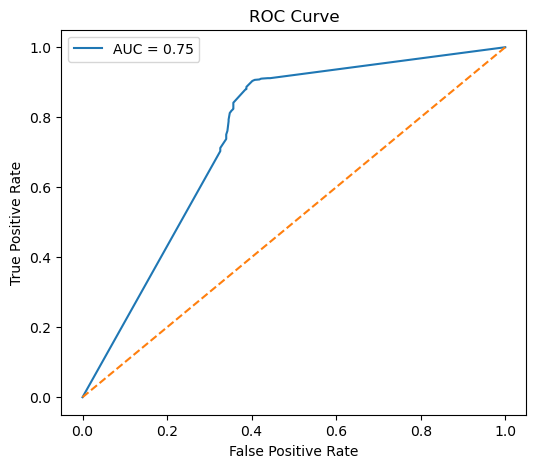

In [80]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

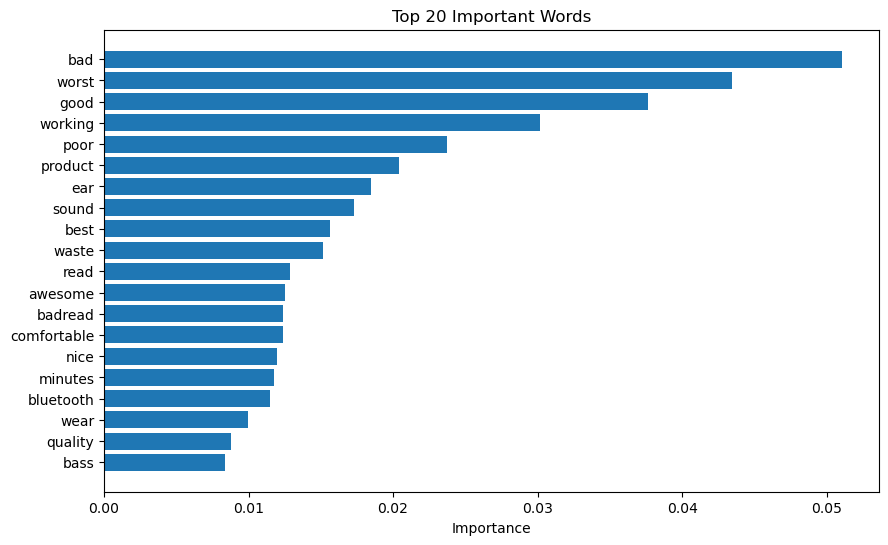

In [81]:
feature_names = vectorizer.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Top 20 Important Words")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [90]:
new_review = ""

# Lowercase
new_review = new_review.lower()

# Remove stopwords
new_review = ' '.join(
    [word for word in new_review.split() if word not in stop_words]
)

# Convert to TF-IDF
new_vector = vectorizer.transform([new_review])

# Predict
prediction = model.predict(new_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Positive Review 😊


In [91]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Function to preprocess a review
def preprocess_text(text):
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

while True:
    review = input("Enter your review (or type 'exit' to quit): ")

    if review.lower() == "exit":
        print("Thank you!")
        break

    # Preprocess
    cleaned_review = preprocess_text(review)

    # Convert to TF-IDF
    review_vector = vectorizer.transform([cleaned_review])

    # Predict
    prediction = model.predict(review_vector)

    if prediction[0] == 1:
        print("😊 Positive Review\n")
    else:
        print("😞 Negative Review\n")

Enter your review (or type 'exit' to quit):  ghgf


😊 Positive Review



Enter your review (or type 'exit' to quit):  hhggh


😊 Positive Review



Enter your review (or type 'exit' to quit):  bad


😞 Negative Review



Enter your review (or type 'exit' to quit):  exit


Thank you!
